# Handwritten Character Recognition - MNIST
### CodeAlpha Machine Learning Internship - Task 3

The goal is to recognize handwritten digits (0-9) from images
using a Convolutional Neural Network (CNN).

Dataset: MNIST (built into Keras)
Model: CNN

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print("libraries imported")

libraries imported


In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("training images:", x_train.shape)
print("test images:", x_test.shape)
print("labels:", np.unique(y_train))

training images: (60000, 28, 28)
test images: (10000, 28, 28)
labels: [0 1 2 3 4 5 6 7 8 9]


---
## 1. Exploratory Data Analysis

Before building the model, I want to look at the data —
what the images look like, how many samples per digit,
and whether the classes are balanced.

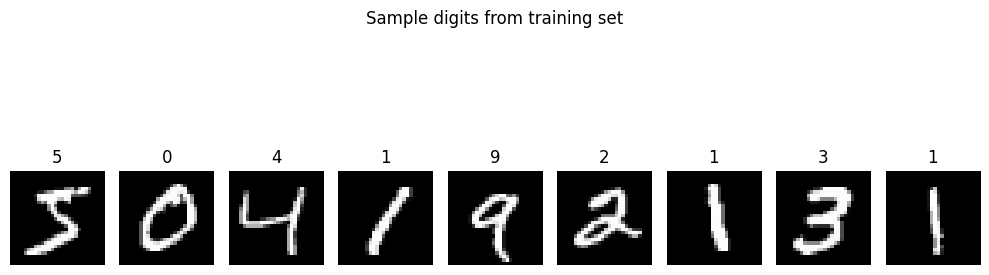

In [3]:
# look at the first 9 images
plt.figure(figsize=(10, 4))
for i in range(9):
    plt.subplot(1, 9, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(str(y_train[i]))
    plt.axis('off')
plt.suptitle('Sample digits from training set')
plt.tight_layout()
plt.savefig('reports/figures/sample_digits.png')
plt.show()

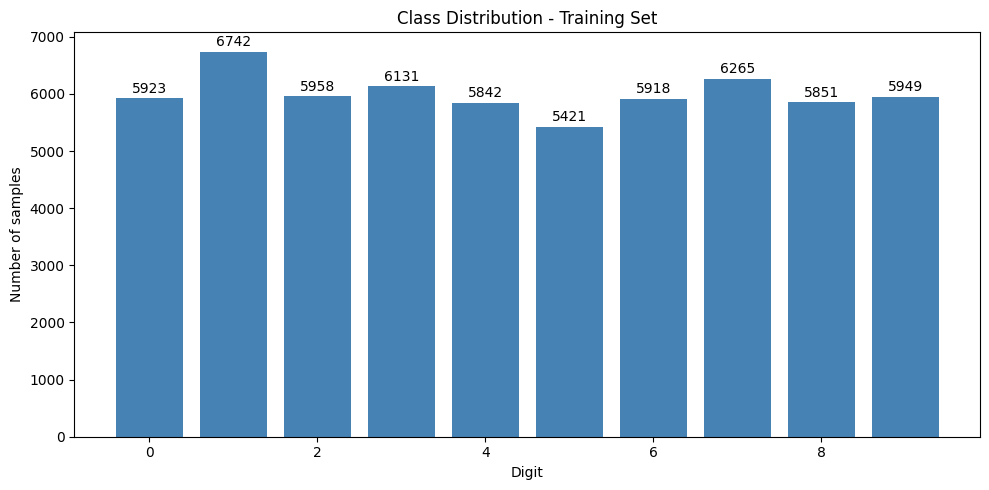

min samples per digit: 5421
max samples per digit: 6742
dataset is balanced: False


In [4]:
# check if classes are balanced
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(unique, counts, color='steelblue')
plt.xlabel('Digit')
plt.ylabel('Number of samples')
plt.title('Class Distribution - Training Set')
for i, count in enumerate(counts):
    plt.text(i, count + 100, str(count), ha='center')
plt.tight_layout()
plt.savefig('reports/figures/class_distribution.png')
plt.show()

print("min samples per digit:", counts.min())
print("max samples per digit:", counts.max())
print("dataset is balanced:", counts.max() - counts.min() < 500)

---
## 2. Data Preprocessing

Preparing the data for the CNN —
reshaping images, normalizing pixel values, and encoding labels.

In [5]:
# CNN expects (samples, height, width, channels)
# MNIST images are grayscale so channel = 1
print("original shape:", x_train.shape)

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test  = x_test.reshape(x_test.shape[0], 28, 28, 1)

print("after reshape:", x_train.shape)

# normalize pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255
x_test  = x_test.astype('float32') / 255

print("pixel range:", x_train.min(), "to", x_train.max())

original shape: (60000, 28, 28)
after reshape: (60000, 28, 28, 1)
pixel range: 0.0 to 1.0


In [6]:
# convert labels to one-hot vectors
# e.g. digit 5 becomes [0,0,0,0,0,1,0,0,0,0]
print("before encoding:", y_train[0])

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

print("after encoding:", y_train[0])
print("label shape:", y_train.shape)

before encoding: 5
after encoding: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
label shape: (60000, 10)


---
## 3. Model Architecture

Building a CNN with two convolutional blocks followed by
fully connected layers. Added Dropout to prevent overfitting.

In [7]:
model = Sequential([
    # first conv block
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # second conv block - more filters to pick up complex patterns
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # flatten and classify
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),  # randomly drops neurons to reduce overfitting
    Dense(10, activation='softmax')  # 10 output classes
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

---
## 4. Model Training

Compiling the model with Adam optimizer and training for 10 epochs.
Using 20% of training data for validation to monitor overfitting.

In [8]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("model compiled")

model compiled


In [9]:
history = model.fit(
    x_train, y_train,
    batch_size=128,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8965 - loss: 0.3348 - val_accuracy: 0.9781 - val_loss: 0.0775
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9673 - loss: 0.1108 - val_accuracy: 0.9828 - val_loss: 0.0589
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9763 - loss: 0.0812 - val_accuracy: 0.9855 - val_loss: 0.0519
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9804 - loss: 0.0638 - val_accuracy: 0.9867 - val_loss: 0.0474
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9828 - loss: 0.0559 - val_accuracy: 0.9877 - val_loss: 0.0439
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9857 - loss: 0.0478 - val_accuracy: 0.9883 - val_loss: 0.0399
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9871 - loss: 0.0421 - val_accuracy: 0.9901 - val_loss: 0.0357
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.9881 - loss: 0.0382 - va

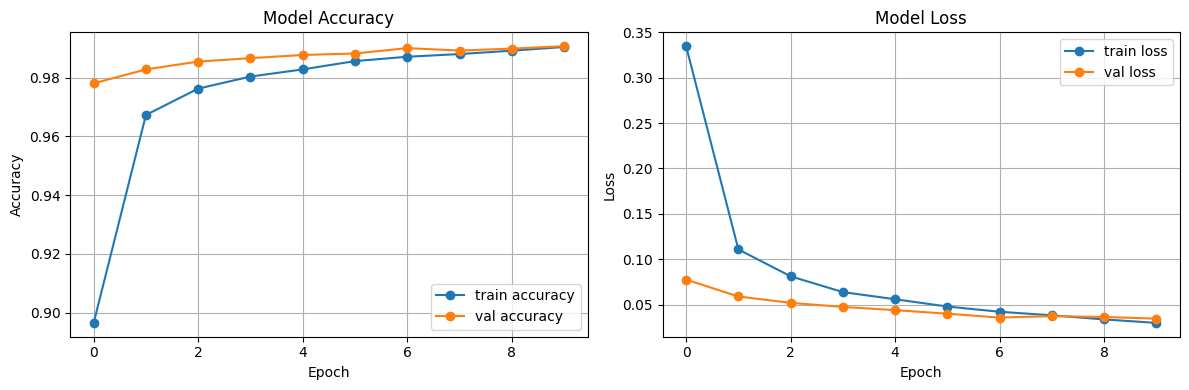

final train accuracy: 0.9905
final val accuracy  : 0.9908


In [10]:
# plot accuracy and loss over epochs
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='val accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss', marker='o')
plt.plot(history.history['val_loss'], label='val loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('reports/figures/training_history.png')
plt.show()

print("final train accuracy:", round(history.history['accuracy'][-1], 4))
print("final val accuracy  :", round(history.history['val_accuracy'][-1], 4))